# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

In [1]:
import pandas as pd

merged_df = pd.read_csv("../data/sf_crime_merged.csv")
merged_df["Incident Date"] = pd.to_datetime(merged_df["Incident Date"])
merged_df = merged_df[merged_df["Incident Date"].dt.year <= 2025]

print("Size of the dataset:", len(merged_df))
print("Columns in the dataset:", merged_df.columns.tolist())

Size of the dataset: 1769353
Columns in the dataset: ['Unified Category', 'Incident Date', 'Incident Time', 'Police District', 'Incident Code', 'Incident Number', 'Incident Description', 'Latitude', 'Longitude', 'Resolution', 'Source']


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# Selected focus crimes with a high accuracy
personal_focus_crimes = [
    "Assault",
    "Burglary",
    "Robbery",
    "Larceny Theft",
    "Motor Vehicle Theft",
    "Fraud",
    "Arson",
    "Forgery And Counterfeiting",
    "Stolen Property",
    "Embezzlement",
    "Prostitution",
    "Missing Person",
    "Warrant",
    "Liquor Laws",
    "Disorderly Conduct",
]
# Filter dataset to personal focus crimes only
focus_df = merged_df[merged_df["Unified Category"].isin(personal_focus_crimes)].copy()
focus_df = focus_df.dropna(subset=["Police District"])
# Normalize district names (the merged data uses both ALL CAPS and Title Case)
focus_df["Police District"] = focus_df["Police District"].str.title()

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

***
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

### Exercise 4.1 — Yearly Crime Counts

Year with most incidents:   2017 (89,419)
Year with fewest incidents: 2025 (51,381)


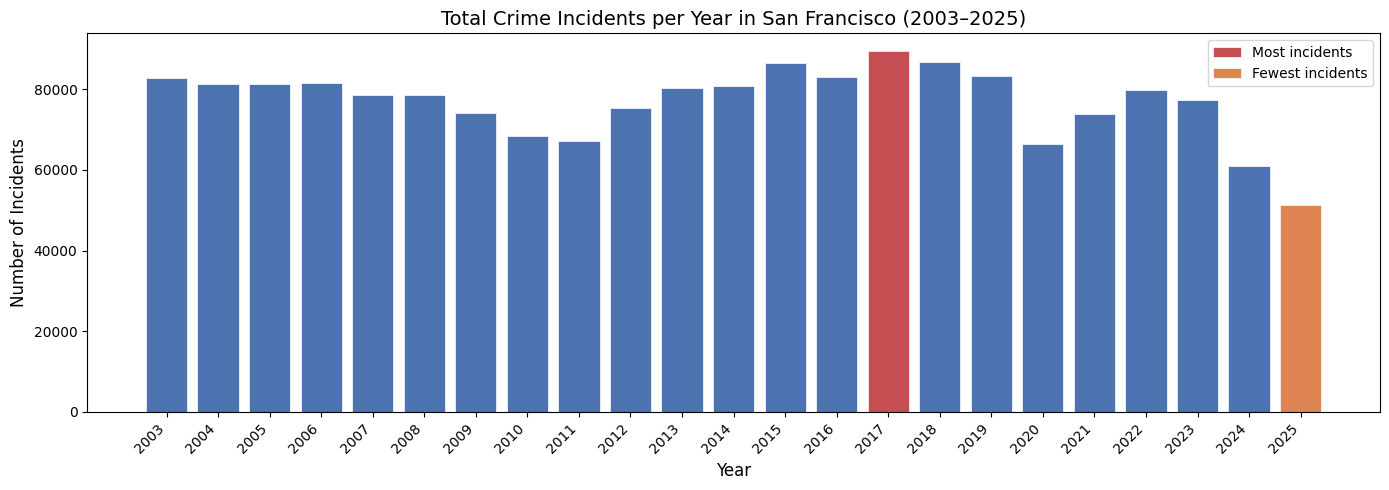

In [3]:
merged_df["Year"] = merged_df["Incident Date"].dt.year

yearly_counts = merged_df.groupby("Year").size()

print(f"Year with most incidents:   {yearly_counts.idxmax()} ({yearly_counts.max():,})")
print(f"Year with fewest incidents: {yearly_counts.idxmin()} ({yearly_counts.min():,})")

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(yearly_counts.index, yearly_counts.values,
              color="#4c72b0", edgecolor="white", linewidth=0.5)

ax.bar(yearly_counts.idxmax(), yearly_counts.max(), color="#c44e52",
       edgecolor="white", linewidth=0.5, label="Most incidents")
ax.bar(yearly_counts.idxmin(), yearly_counts.min(), color="#dd8452",
       edgecolor="white", linewidth=0.5, label="Fewest incidents")

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Total Crime Incidents per Year in San Francisco (2003–2025)", fontsize=14)
ax.set_xticks(yearly_counts.index)
ax.set_xticklabels(yearly_counts.index.astype(int), rotation=45, ha="right")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Exercise 4.2 — Focus Crime Trends (Year-by-Year Subplots)

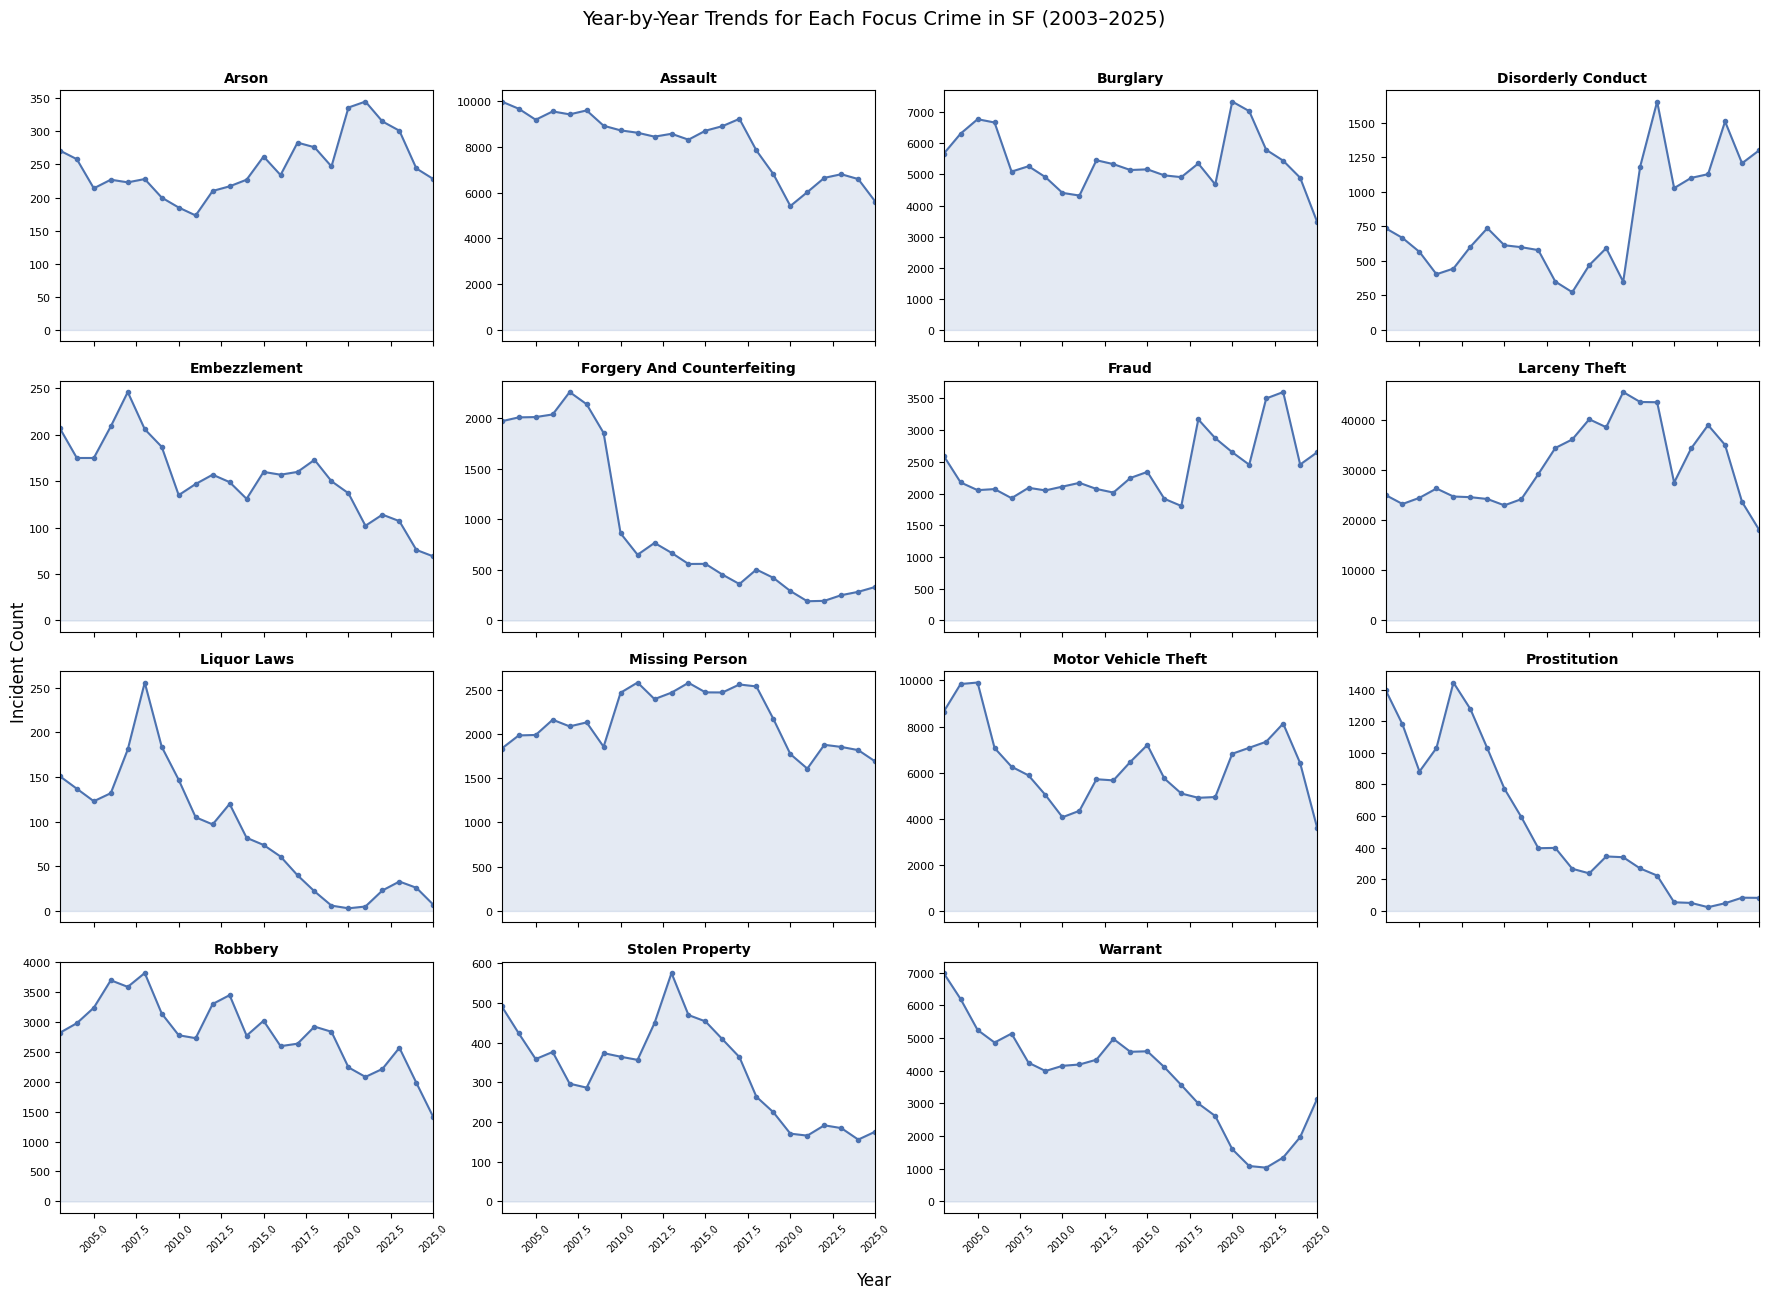

In [4]:
focus_df["Year"] = focus_df["Incident Date"].dt.year

sorted_crimes = sorted(personal_focus_crimes)
ncols = 4
nrows = -(-len(sorted_crimes) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2), sharex=True)
axes = axes.flatten()

for i, crime in enumerate(sorted_crimes):
    ax = axes[i]
    crime_yearly = (
        focus_df[focus_df["Unified Category"] == crime]
        .groupby("Year")
        .size()
        .reindex(range(2003, 2026), fill_value=0)
    )
    ax.plot(crime_yearly.index, crime_yearly.values,
            marker="o", markersize=3, linewidth=1.5, color="#4c72b0")
    ax.fill_between(crime_yearly.index, crime_yearly.values, alpha=0.15, color="#4c72b0")
    ax.set_title(crime, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlim(2003, 2025)

for j in range(len(sorted_crimes), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Year-by-Year Trends for Each Focus Crime in SF (2003–2025)",
             fontsize=14, y=1.01)
fig.supxlabel("Year", fontsize=12)
fig.supylabel("Incident Count", fontsize=12)

plt.tight_layout()
plt.show()

### Discussion — Assignment 1.1

Looking at the overall trends, two things that we can point out:

**The 2020 COVID drop**. Total crime incidents droped in 2020, which makes sense given the lockdowns. With fewer people out on the streets, there were simply fewer opportunities for crimes like Larceny Theft and Robbery that typically happen in public spaces. It's also possible that reporting patterns changed during the health emergency.

**The peak around 2017**. Crime incidents hit their highest point around 2017 (roughly 87,000) and have been declining ever since. This could reflect shifting police priorities, changes in how crimes are reported, or deeper demographic and economic shifts in San Francisco. The pandemic may have accelerated some of these longer-term trends as well.

Looking at individual crime types reveals some interesting patterns:

**Fraud and Warrants went up in 2020**. While most crimes dropped during the pandemic, Fraud and Warrant incidents actually increased. Fraud likely rose because people were spending more time online, creating more opportunities for scams. Warrants might reflect changes in how policing worked during COVID, or perhaps courts were dealing with backlogs differently.

**Some crimes are disappearing**. Forgery, Prostitution, and Liquor Law violations have all been declining steadily over the past 20 years. This probably reflects broader changes: electronic payments have made forgery harder, social attitudes have shifted, and enforcement priorities have changed over time.

### Part B — Probability plot

### Exercise 2.1 — Crime Profiles by Police District

We compute the conditional crime profile for each district:

$$r(\text{crime},\;\text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$

A ratio above 1 means the crime is **over-represented** in that district; below 1 means **under-represented**.

SF police districts (10):
Bayview, Central, Ingleside, Mission, Northern, Park, Richmond, Southern, Taraval, Tenderloin

Most total crimes (all categories): Southern  (295,253)
Most Personal Focus Crimes:          Southern  (252,325)
Fewest total crimes:                 Park  (95,733)


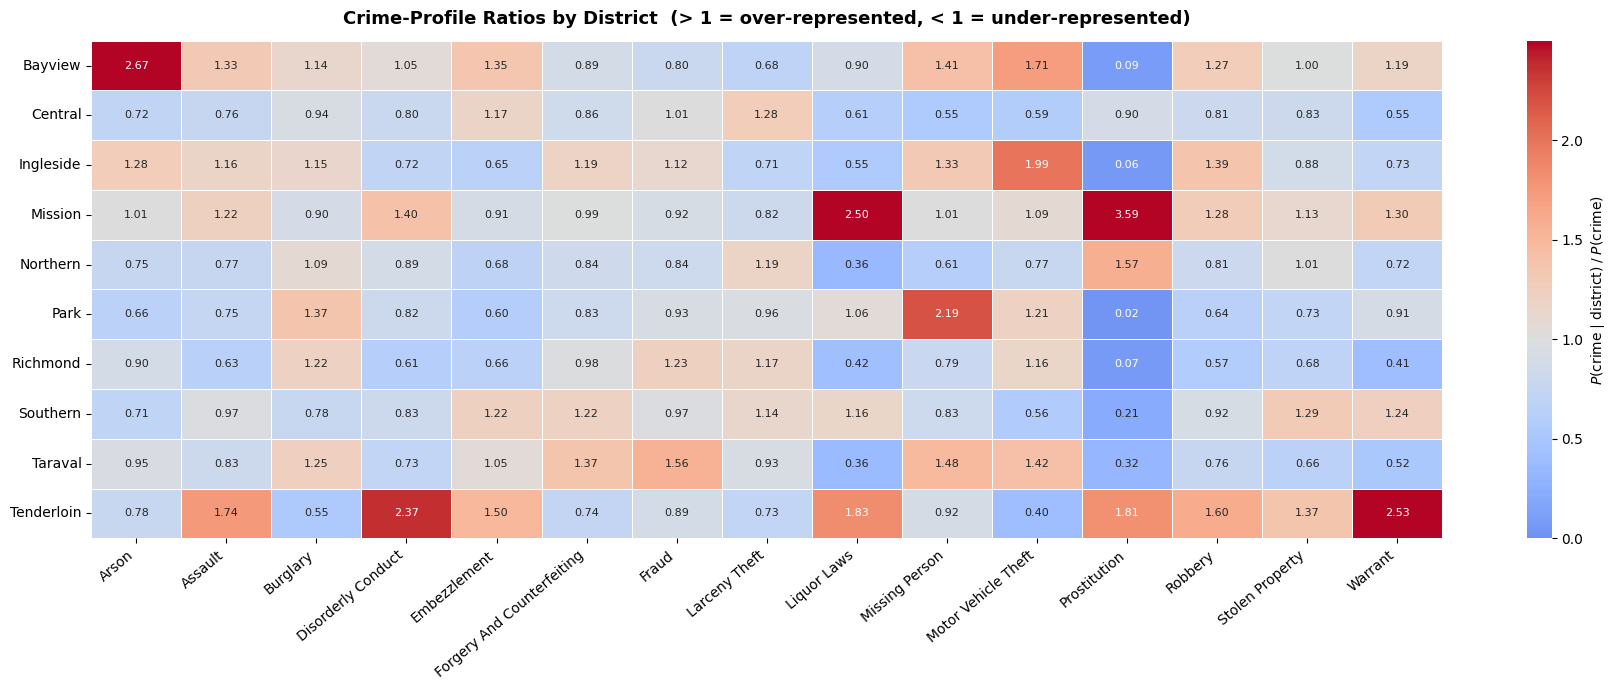


Top 5 over-represented crimes in Tenderloin:
Unified Category
Warrant               2.532
Disorderly Conduct    2.368
Liquor Laws           1.835
Prostitution          1.807
Assault               1.743

Top 5 over-represented crimes in Mission:
Unified Category
Prostitution          3.590
Liquor Laws           2.498
Disorderly Conduct    1.400
Warrant               1.300
Robbery               1.280

Top 5 over-represented crimes in Richmond:
Unified Category
Fraud                         1.226
Burglary                      1.216
Larceny Theft                 1.171
Motor Vehicle Theft           1.161
Forgery And Counterfeiting    0.978

Potentially unstable ratios  (ratio > 2.5 AND < 30 incidents):
  None found — all high ratios are backed by sufficient counts.

Lowest-volume district: Park  (95,733 total crimes)
  Ratio dispersion (std): 0.467
  Median across all districts: 0.427


In [5]:
DISTRICT_COL = "Police District"
CRIME_COL = "Unified Category"

# Work with the 10 actual SF districts (exclude "Out Of Sf")
all_df = merged_df.dropna(subset=[DISTRICT_COL]).copy()
all_df[DISTRICT_COL] = all_df[DISTRICT_COL].str.title()
all_df = all_df[all_df[DISTRICT_COL] != "Out Of Sf"]

focus_local = all_df[all_df[CRIME_COL].isin(personal_focus_crimes)].copy()

# ── District listing ──
district_names = sorted(all_df[DISTRICT_COL].unique())
print(f"SF police districts ({len(district_names)}):")
print(", ".join(district_names))

# ── Which district has the most crimes? ──
all_counts = all_df.groupby(DISTRICT_COL).size().sort_values(ascending=False)
focus_counts = focus_local.groupby(DISTRICT_COL).size().sort_values(ascending=False)

print(f"\nMost total crimes (all categories): {all_counts.index[0]}  ({all_counts.iloc[0]:,})")
print(f"Most Personal Focus Crimes:          {focus_counts.index[0]}  ({focus_counts.iloc[0]:,})")
print(f"Fewest total crimes:                 {all_counts.index[-1]}  ({all_counts.iloc[-1]:,})")

# ── P(crime) — city-wide base rate within focus crimes ──
p_crime = focus_local[CRIME_COL].value_counts(normalize=True)

# ── P(crime | district) ──
p_crime_given_district = pd.crosstab(
    focus_local[DISTRICT_COL], focus_local[CRIME_COL], normalize="index"
).reindex(columns=personal_focus_crimes, fill_value=0)

# ── Ratio matrix ──
ratio = p_crime_given_district.div(p_crime, axis=1)

# ── Annotated heatmap ──
fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    ratio,
    ax=ax,
    cmap="coolwarm",
    center=1.0,
    vmin=0.0,
    vmax=float(np.nanpercentile(ratio.values, 98)),
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": r"$P(\mathrm{crime}\mid\mathrm{district})\;/\;P(\mathrm{crime})$"},
)
ax.set_title(
    "Crime-Profile Ratios by District  (> 1 = over-represented, < 1 = under-represented)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# ── Top over-represented crimes for key districts ──
for district in ["Tenderloin", "Mission", "Richmond"]:
    top = ratio.loc[district].sort_values(ascending=False).head(5)
    print(f"\nTop 5 over-represented crimes in {district}:")
    print(top.round(3).to_string())

# ── Suspicious extreme ratios (high ratio but few incidents) ──
count_matrix = pd.crosstab(
    focus_local[DISTRICT_COL], focus_local[CRIME_COL]
).reindex(index=ratio.index, columns=ratio.columns, fill_value=0)

flat = ratio.stack().rename("ratio").to_frame().join(count_matrix.stack().rename("count"))
suspicious = flat[(flat["ratio"] > 2.5) & (flat["count"] < 30)].sort_values(
    "ratio", ascending=False
)
print("\nPotentially unstable ratios  (ratio > 2.5 AND < 30 incidents):")
if suspicious.empty:
    print("  None found — all high ratios are backed by sufficient counts.")
else:
    print(suspicious.round(3).to_string())

# ── Lowest-volume district noise check ──
lowest = all_counts.idxmin()
ratio_std = ratio.std(axis=1).sort_values(ascending=False)
print(f"\nLowest-volume district: {lowest}  ({all_counts[lowest]:,} total crimes)")
print(f"  Ratio dispersion (std): {ratio_std[lowest]:.3f}")
print(f"  Median across all districts: {ratio_std.median():.3f}")

### Discussion — Exercise 2.1

The **Tenderloin** stands out immediately as the most distinctive district, with sharply elevated ratios for Warrant (2.5×), Disorderly Conduct (2.4×), Liquor Laws (1.8×), Prostitution (1.8×), and Assault (1.7×). This fits well with the neighbourhood's known character — high rates of homelessness, open-air substance use, and street-level disorder. The especially high Warrant ratio likely reflects concentrated enforcement against individuals cycling through the justice system.

Beyond the Tenderloin, the **Mission** also stands out as an outlier in several categories, while **Richmond** has a near-zero Prostitution ratio — consistent with its primarily residential character. A subtler but interesting pattern is **Bayview's** elevated Embezzlement ratio (1.35×), which is easy to miss visually in the heatmap but worth noting as a distinctive local feature.

### Exercise 2.2 — How do crime profiles change over time?

We split the data into an **early** (2003–2008) and **late** (2020–2025) period, recompute the ratio for each, and visualize both periods plus the difference.

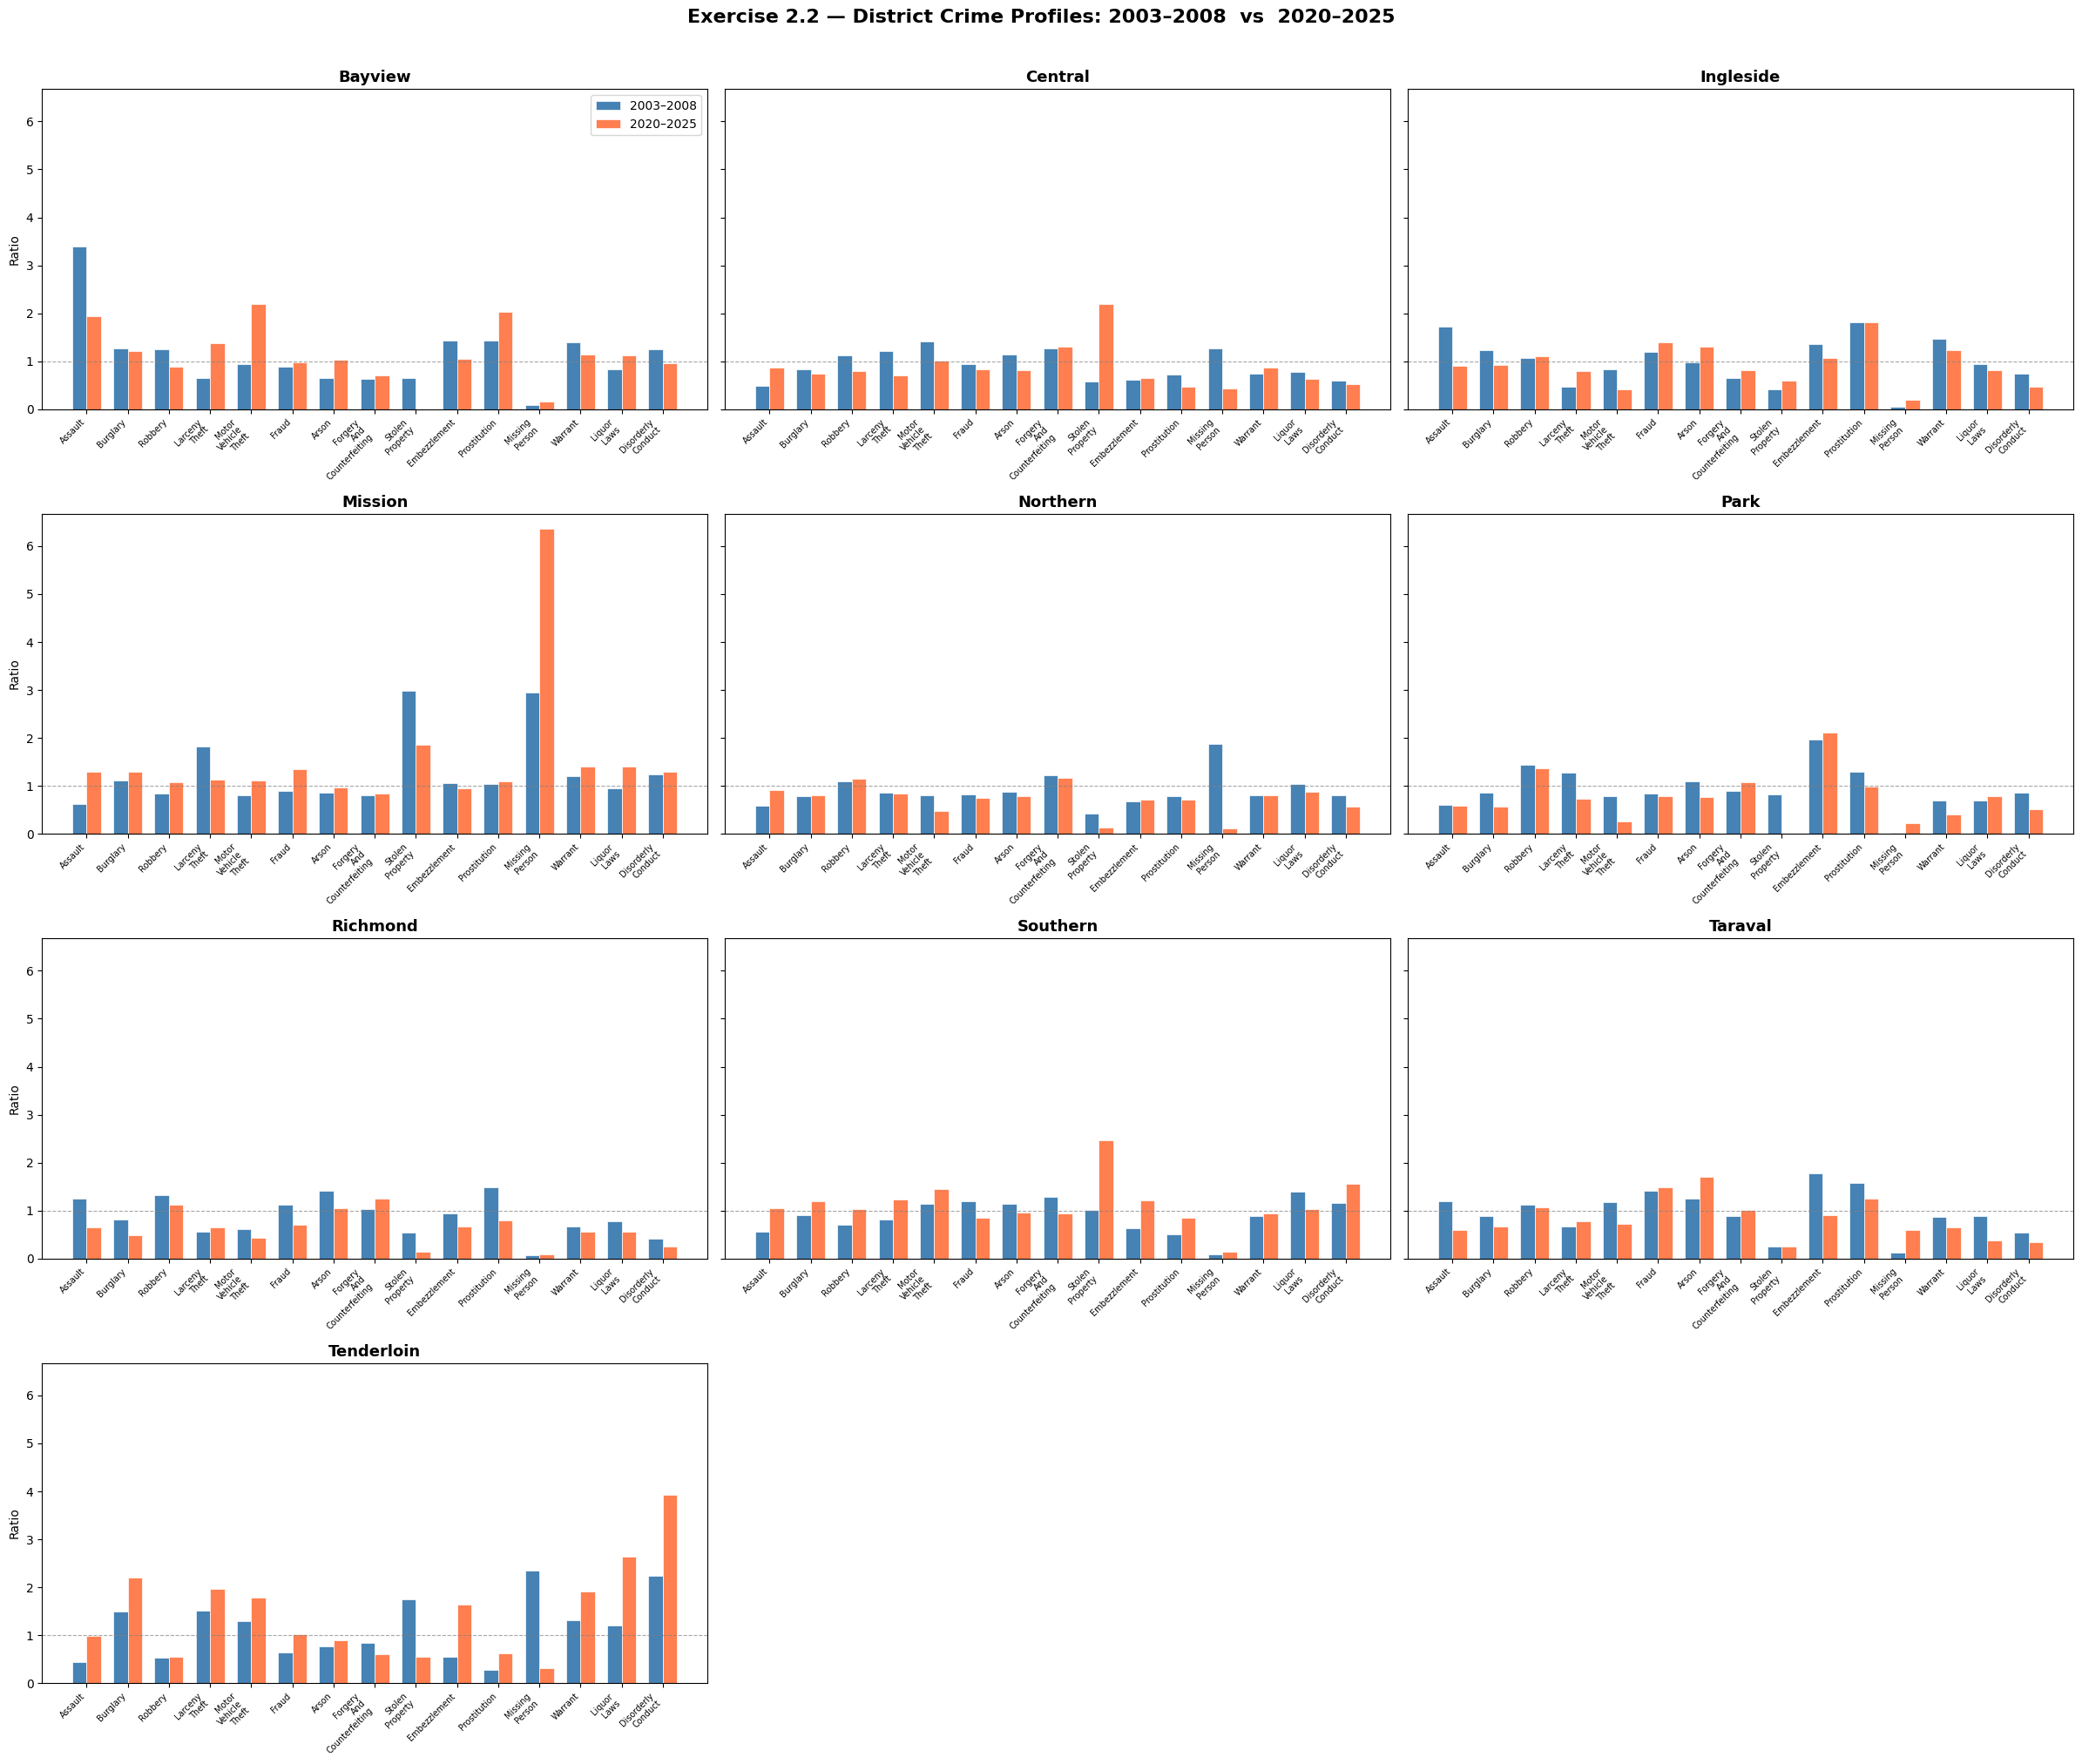

District that changed the most  (L2 distance between ratio vectors):
Police District
Mission       3.814
Tenderloin    3.694
Bayview       2.380
Central       2.067
Southern      1.964
Northern      1.875
Taraval       1.519
Park          1.360
Richmond      1.313
Ingleside     1.229

Crime types with the largest average shift across districts:
Unified Category
Liquor Laws            -0.123
Arson                  -0.107
Stolen Property        +0.073
Warrant                +0.053
Motor Vehicle Theft    -0.034
Burglary               -0.034
Disorderly Conduct     +0.033
Larceny Theft          +0.023


In [6]:
focus_local["Year"] = focus_local["Incident Date"].dt.year


def compute_ratio(subset):
    """P(crime|district) / P(crime) for a time-filtered subset."""
    base = subset[CRIME_COL].value_counts(normalize=True)
    cond = pd.crosstab(
        subset[DISTRICT_COL], subset[CRIME_COL], normalize="index"
    ).reindex(columns=personal_focus_crimes, fill_value=0)
    return cond.div(base, axis=1)


ratio_early = compute_ratio(focus_local[focus_local["Year"].between(2003, 2008)])
ratio_late = compute_ratio(focus_local[focus_local["Year"].between(2020, 2025)])

common_districts = sorted(set(ratio_early.index) & set(ratio_late.index))
ratio_early = ratio_early.loc[common_districts]
ratio_late = ratio_late.loc[common_districts]

# ── Side-by-side grouped bar charts — one subplot per district ──
n_districts = len(common_districts)
ncols = 3
nrows = -(-n_districts // ncols)
crime_labels = [c.replace(" ", "\n") for c in personal_focus_crimes]
x = np.arange(len(personal_focus_crimes))
bar_width = 0.35

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 5 * nrows), sharey=True)
axes_flat = axes.flatten()

for idx, district in enumerate(common_districts):
    ax = axes_flat[idx]
    early_vals = ratio_early.loc[district].values
    late_vals = ratio_late.loc[district].values

    ax.bar(x - bar_width / 2, early_vals, bar_width,
           label="2003–2008", color="steelblue", edgecolor="white", linewidth=0.5)
    ax.bar(x + bar_width / 2, late_vals, bar_width,
           label="2020–2025", color="coral", edgecolor="white", linewidth=0.5)
    ax.axhline(y=1, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_title(district, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(crime_labels, fontsize=7, rotation=45, ha="right")
    ax.set_ylabel("Ratio" if idx % ncols == 0 else "")

for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

axes_flat[0].legend(fontsize=10, loc="upper right")
fig.suptitle(
    "Exercise 2.2 — District Crime Profiles: 2003–2008  vs  2020–2025",
    fontsize=16, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()

# ── Quantify "changed the most" via L2 distance between ratio vectors ──
shift_l2 = (
    np.sqrt(((ratio_late - ratio_early) ** 2).sum(axis=1))
    .sort_values(ascending=False)
)
crime_shift = (ratio_late - ratio_early).mean(axis=0)
crime_shift = crime_shift.reindex(crime_shift.abs().sort_values(ascending=False).index)

print("District that changed the most  (L2 distance between ratio vectors):")
print(shift_l2.round(3).to_string())

print("\nCrime types with the largest average shift across districts:")
print(crime_shift.round(3).head(8).map(lambda v: f"{v:+.3f}").to_string())

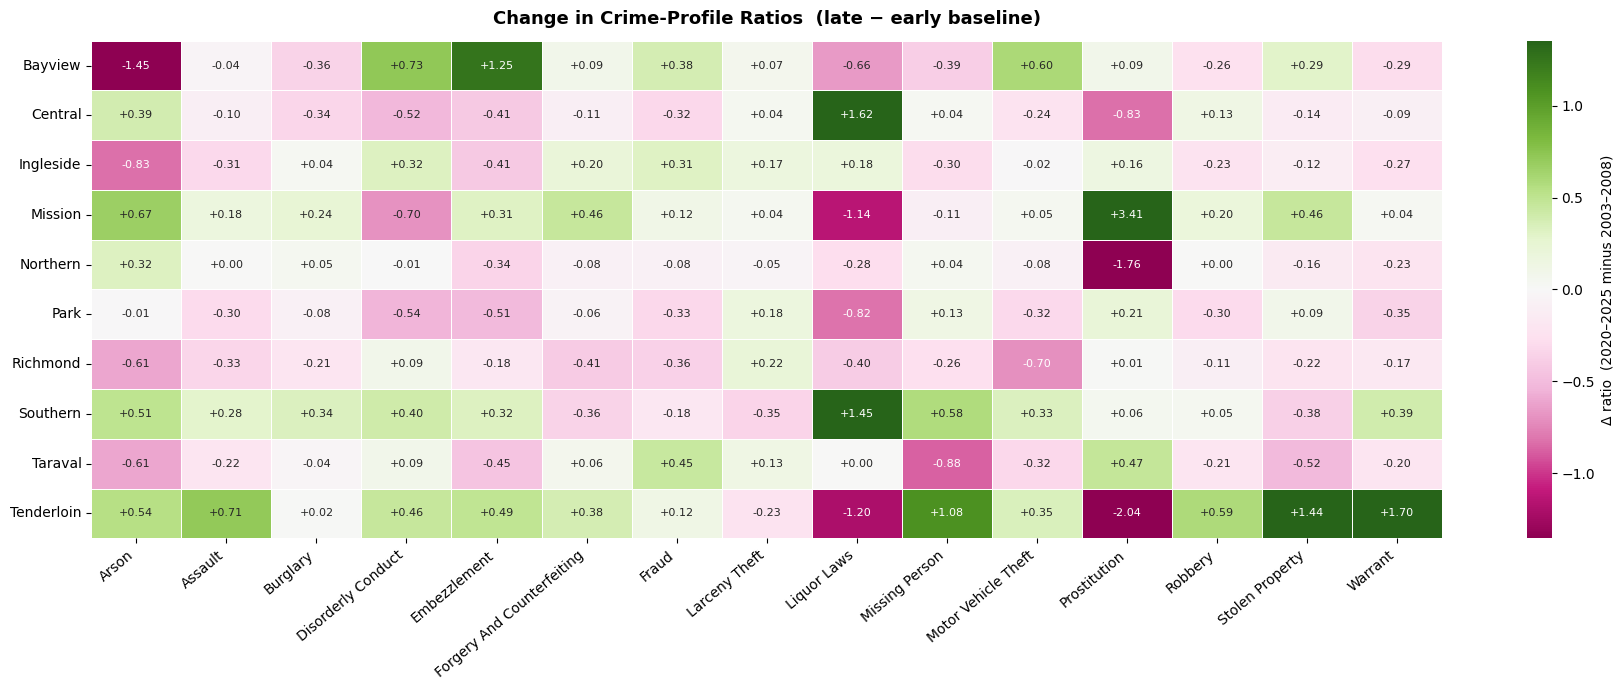

In [7]:
ratio_diff = ratio_late - ratio_early
diff_max = float(np.nanpercentile(np.abs(ratio_diff.values), 95))

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    ratio_diff,
    ax=ax,
    cmap="PiYG",
    center=0,
    vmin=-diff_max,
    vmax=diff_max,
    linewidths=0.5,
    linecolor="white",
    annot=True,
    fmt="+.2f",
    annot_kws={"fontsize": 8},
    cbar_kws={"label": "Δ ratio  (2020–2025 minus 2003–2008)"},
)
ax.set_title(
    "Change in Crime-Profile Ratios  (late − early baseline)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=40, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### Discussion — Exercise 2.2

**How we measured change:** We treat each district's vector of 15 ratios as a point in 15-dimensional space and compare early vs. late using Euclidean distance. A larger distance means the overall crime mix shifted more.

**The two districts that changed the most** are the Mission (L2 ≈ 3.8) and the Tenderloin (L2 ≈ 3.7), and both changes are dominated by Prostitution. The Mission's Prostitution ratio jumped by roughly +3.4 — the single largest cell-level swing in the entire matrix — while the Tenderloin's dropped by about −2.0 and its Warrant ratio climbed by +1.7. It looks like enforcement pressure migrated out of the Tenderloin/Northern corridors, and activity followed it into the Mission's mixed-use blocks. Meanwhile, the Tenderloin shifted toward warrant-based policing targeting repeat offenders.

**Prostitution is the crime type that shifted the most overall** (average absolute change of 0.90 across districts). This isn't a city-wide increase or decrease — it's geographic displacement, probably driven by changing policing strategies and neighbourhood composition.

A couple of other notable shifts: Central (North Beach / Chinatown nightlife) saw Liquor Laws rise by +1.6, likely tied to more alcohol-related enforcement during the post-pandemic outdoor-dining boom. And Bayview's Arson ratio fell by −1.4, which lines up with the redevelopment of formerly vacant industrial parcels like Hunters Point Shipyard — fewer empty buildings means fewer arson targets.

**What this means for predictive policing:** These shifts are substantial — Mission's profile moved by nearly 4 units over 15 years. A model trained on 2003–2008 data would systematically over-predict Prostitution in the Tenderloin and under-predict it in the Mission. Crime patterns are clearly non-stationary: they evolve with gentrification, policy changes, and economic shifts. Any predictive model trained on historical data needs regular retraining or, better, explicit monitoring for distribution drift to stay useful.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?